## Milestone II - Feature Selection

Systematic feature selection to reduce the 234-feature space before final model development.

**Input:** `data/milestone_ii_preprocessed.pkl`

**Output:** `data/selected_features.pkl` (final selected feature list)

**Pipeline:**
1. Correlation-based redundancy removal (|r| > 0.90)
2. Permutation importance via cross-validated XGBoost
3. LASSO (L1) logistic regression selection
4. Consensus summary + final feature set

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# ── Data Setup (identical to Baseline notebook) ──────────────────────────────
df = pd.read_pickle('data/milestone_ii_preprocessed.pkl')
df_flat = df.reset_index()
df_flat = df_flat[df_flat['date'] < '2019-01-01']

leaky_cols = ['oecd_rec', 'technical_rec', 'pre_recession']
non_feature_cols = ['date', 'country']
feature_cols = [c for c in df_flat.columns if c not in leaky_cols + non_feature_cols]

X = df_flat[feature_cols].copy()
y = df_flat['pre_recession']
X = X.replace([np.inf, -np.inf], np.nan)

scale_pos_weight = (y == 0).sum() / (y == 1).sum()

print(f'Observations: {len(X)}')
print(f'Features:     {len(feature_cols)}')
print(f'Positive class: {y.sum()} ({y.mean():.1%})')
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

Observations: 5292
Features:     234
Positive class: 1111 (21.0%)
scale_pos_weight: 3.76


### Step 1: Correlation-Based Redundancy Removal

Remove features that are nearly perfectly correlated (|r| > 0.90). For each
correlated pair, the feature with lower XGBoost gain importance is dropped.
This reduces multicollinearity and computational cost for subsequent steps.

In [2]:
# Train a single XGBoost model on all data for stable gain-based importance ranking
# Used to decide WHICH member of a correlated pair to drop

model_ref = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
model_ref.fit(X, y)

gain_importance = pd.Series(
    model_ref.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print('Top 10 features by XGBoost gain importance:')
print(gain_importance.head(10).to_string())

Top 10 features by XGBoost gain importance:
cli                                               0.033888
real_gdp_log_6mo                                  0.024364
unemployment_rate_lag_1mo                         0.018161
cli_lag_1mo                                       0.015816
copper_lag_6mo                                    0.011332
gps_log_12mo                                      0.011250
vix_rolling_mean_6mo_lag_12mo                     0.010229
national_share_price_rolling_mean_3mo_lag_12mo    0.010176
vix_rolling_mean_12mo_lag_12mo                    0.010014
3_mo_yld_lag_6mo                                  0.009970


In [3]:
# Compute pairwise correlation and identify high-correlation pairs
corr_matrix = X.corr()

threshold = 0.90
high_corr_pairs = []

corr_upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

for col in corr_upper.columns:
    for row in corr_upper.index:
        val = corr_upper.loc[row, col]
        if pd.notna(val) and abs(val) > threshold:
            imp_row = gain_importance.get(row, 0)
            imp_col = gain_importance.get(col, 0)
            drop_feature = row if imp_row < imp_col else col
            keep_feature = col if drop_feature == row else row
            high_corr_pairs.append({
                'feature_a': row,
                'feature_b': col,
                'correlation': round(val, 4),
                'drop': drop_feature,
                'keep': keep_feature
            })

pairs_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', key=abs, ascending=False)
print(f'High-correlation pairs found (|r| > {threshold}): {len(pairs_df)}')
print(pairs_df.head(20).to_string(index=False))

High-correlation pairs found (|r| > 0.9): 444
                  feature_a                       feature_b  correlation                            drop                        keep
 comp_consumer_conf_lag_6mo  comp_consumer_conf_dev_lag_6mo       1.0000  comp_consumer_conf_dev_lag_6mo  comp_consumer_conf_lag_6mo
comp_consumer_conf_lag_12mo comp_consumer_conf_dev_lag_12mo       1.0000 comp_consumer_conf_dev_lag_12mo comp_consumer_conf_lag_12mo
 comp_consumer_conf_lag_1mo  comp_consumer_conf_dev_lag_1mo       1.0000  comp_consumer_conf_dev_lag_1mo  comp_consumer_conf_lag_1mo
 comp_consumer_conf_lag_3mo  comp_consumer_conf_dev_lag_3mo       1.0000  comp_consumer_conf_dev_lag_3mo  comp_consumer_conf_lag_3mo
                cli_lag_6mo                 cli_dev_lag_6mo       1.0000                 cli_dev_lag_6mo                 cli_lag_6mo
         retail_vol_lag_1mo              retail_vol_lag_3mo       1.0000              retail_vol_lag_1mo          retail_vol_lag_3mo
                cli_lag

In [4]:
# Remove redundant features, resolving conflicts where a feature is both
# 'keep' in one pair and 'drop' in another
features_to_drop_corr = set(pairs_df['drop'].tolist())
keep_set = set(pairs_df['keep'].tolist())
conflict = features_to_drop_corr & keep_set
for feat in conflict:
    features_to_drop_corr.discard(feat)

features_after_corr = [f for f in feature_cols if f not in features_to_drop_corr]

print(f'Features before correlation removal: {len(feature_cols)}')
print(f'Features dropped:                    {len(features_to_drop_corr)}')
print(f'Features remaining:                  {len(features_after_corr)}')
print(f'\nDropped features:')
for f in sorted(features_to_drop_corr):
    print(f'  {f}')

Features before correlation removal: 234
Features dropped:                    26
Features remaining:                  208

Dropped features:
  3_mo_yld_lag_3mo
  cli_dev_lag_12mo
  cli_dev_lag_6mo
  cli_diff_6mo
  comp_consumer_conf_dev_lag_12mo
  comp_consumer_conf_dev_lag_6mo
  copper_lag_1mo
  country_Australia
  cpi_yoy_pct
  epu
  epu_lag_12mo
  epu_rolling_mean_3mo_lag_3mo
  gdp_qoq_growth
  ind_out_lag_1mo
  national_share_price_lag_1mo
  real_rate_10yr_lag_1mo
  real_rate_10yr_lag_6mo
  real_rate_3mo_lag_3mo
  sahm_value_lag_1mo
  unemployment_rate_lag_3mo
  vix_lag_12mo
  vix_lag_6mo
  vix_rolling_mean_12mo_lag_12mo
  vix_rolling_mean_12mo_lag_1mo
  vix_rolling_mean_3mo_lag_1mo
  yield_curve_lag_1mo


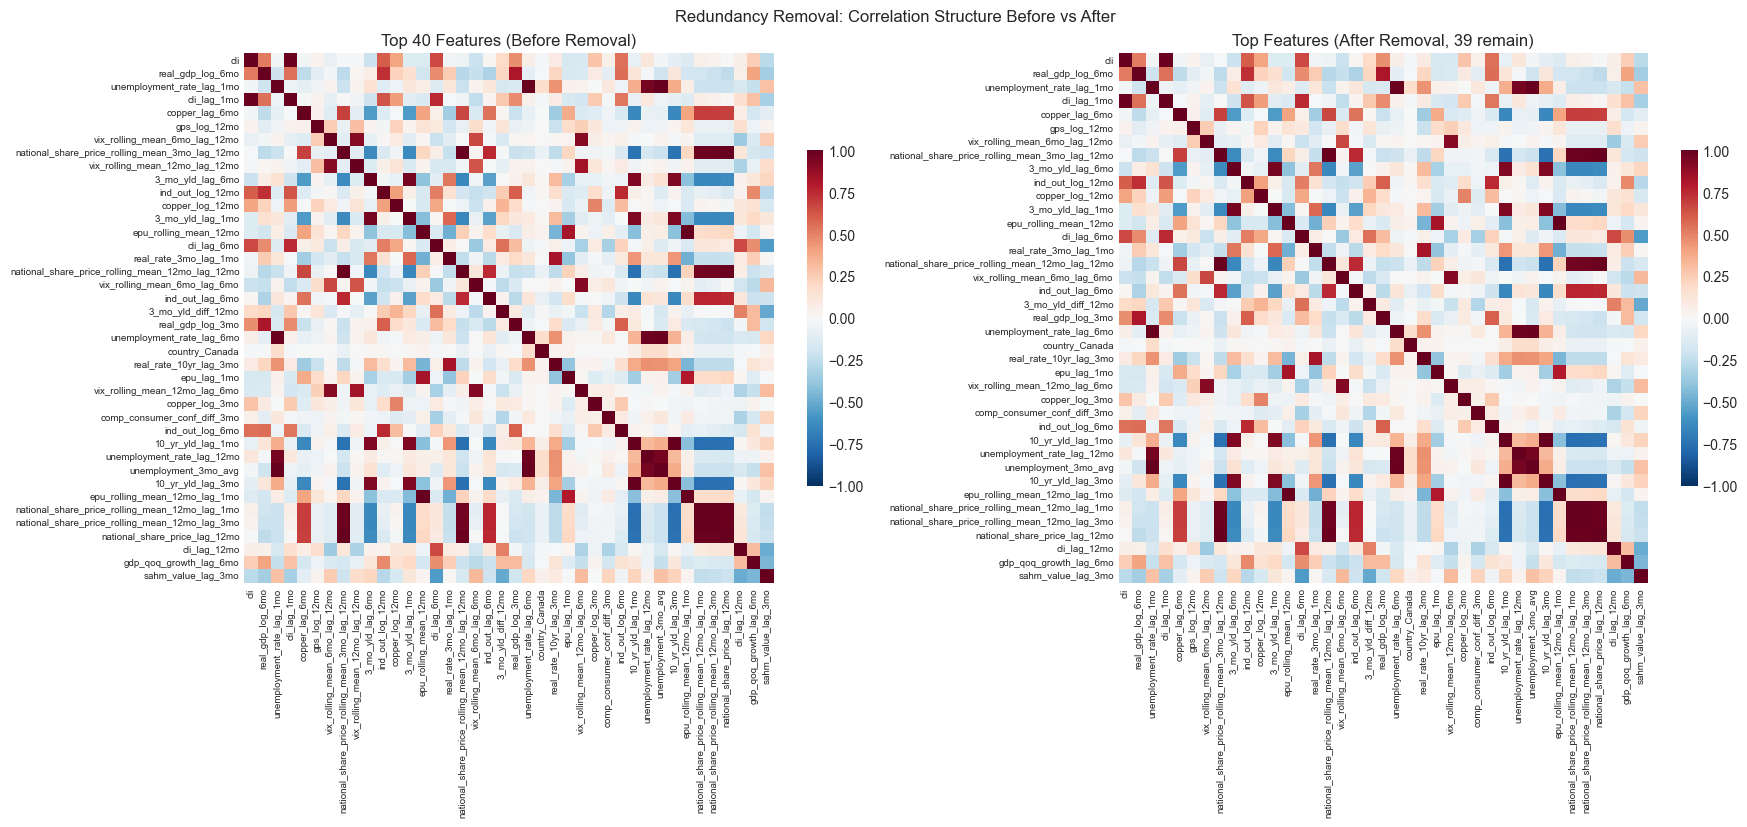

In [5]:
# Correlation heatmap: top features before vs after removal
top_n_heatmap = 40
top_features_heatmap = gain_importance.head(top_n_heatmap).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

corr_before = X[top_features_heatmap].corr()
sns.heatmap(
    corr_before, ax=axes[0], cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, square=True,
    xticklabels=True, yticklabels=True,
    cbar_kws={'shrink': 0.6}
)
axes[0].set_title(f'Top {top_n_heatmap} Features (Before Removal)')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

top_after = [f for f in top_features_heatmap if f in features_after_corr]
corr_after = X[top_after].corr()
sns.heatmap(
    corr_after, ax=axes[1], cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, square=True,
    xticklabels=True, yticklabels=True,
    cbar_kws={'shrink': 0.6}
)
axes[1].set_title(f'Top Features (After Removal, {len(top_after)} remain)')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

plt.suptitle('Redundancy Removal: Correlation Structure Before vs After', fontsize=12)
plt.tight_layout()
plt.show()

### Step 2: Permutation Importance (Cross-Validated)

Permutation importance measures the drop in ROC-AUC when a feature's values are
randomly shuffled on the held-out test fold. Unlike gain-based importance,
permutation importance is not biased toward high-cardinality features and
directly measures predictive contribution on unseen data.

Each fold contributes an importance estimate; the mean and std across 5 folds
give a stable, uncertainty-aware ranking.

In [6]:
# Cross-validated permutation importance on the correlation-reduced feature set
X_reduced = X[features_after_corr].copy()
tscv = TimeSeriesSplit(n_splits=5)

fold_importances = []
fold_roc_aucs = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_reduced)):
    X_train = X_reduced.iloc[train_idx]
    X_test = X_reduced.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    spw = (y_train == 0).sum() / (y_train == 1).sum()

    model_fold = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=spw,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    model_fold.fit(X_train, y_train)

    y_proba = model_fold.predict_proba(X_test)[:, 1]
    fold_roc_aucs.append(roc_auc_score(y_test, y_proba))

    perm_result = permutation_importance(
        model_fold, X_test, y_test,
        n_repeats=5,
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1
    )
    fold_importances.append(perm_result.importances_mean)

    print(f'Fold {fold + 1}: ROC-AUC = {fold_roc_aucs[-1]:.3f}')

# Aggregate across folds
perm_mean = np.mean(fold_importances, axis=0)
perm_std = np.std(fold_importances, axis=0)

perm_df = pd.DataFrame({
    'feature': features_after_corr,
    'perm_mean': perm_mean,
    'perm_std': perm_std
}).sort_values('perm_mean', ascending=False).reset_index(drop=True)

print(f'\nCV ROC-AUC on reduced feature set: {np.mean(fold_roc_aucs):.3f} \u00b1 {np.std(fold_roc_aucs):.3f}')
print(f'\nTop 20 features by permutation importance:')
print(perm_df.head(20).to_string(index=False))

Fold 1: ROC-AUC = 0.679
Fold 2: ROC-AUC = 0.703
Fold 3: ROC-AUC = 0.717
Fold 4: ROC-AUC = 0.776
Fold 5: ROC-AUC = 0.583

CV ROC-AUC on reduced feature set: 0.692 ± 0.063

Top 20 features by permutation importance:
                                        feature  perm_mean  perm_std
                                            cli   0.101253  0.051193
                                  cli_diff_12mo   0.016344  0.024203
                                    cli_lag_1mo   0.005713  0.003734
                                   cpi_log_12mo   0.005162  0.004710
                                       3_mo_yld   0.003600  0.001794
                              real_gdp_log_12mo   0.003582  0.005395
                               ind_out_log_12mo   0.003315  0.001493
national_share_price_rolling_mean_12mo_lag_12mo   0.002722  0.001896
                                    cli_lag_3mo   0.002387  0.002313
                                 copper_lag_6mo   0.002350  0.003033
                           

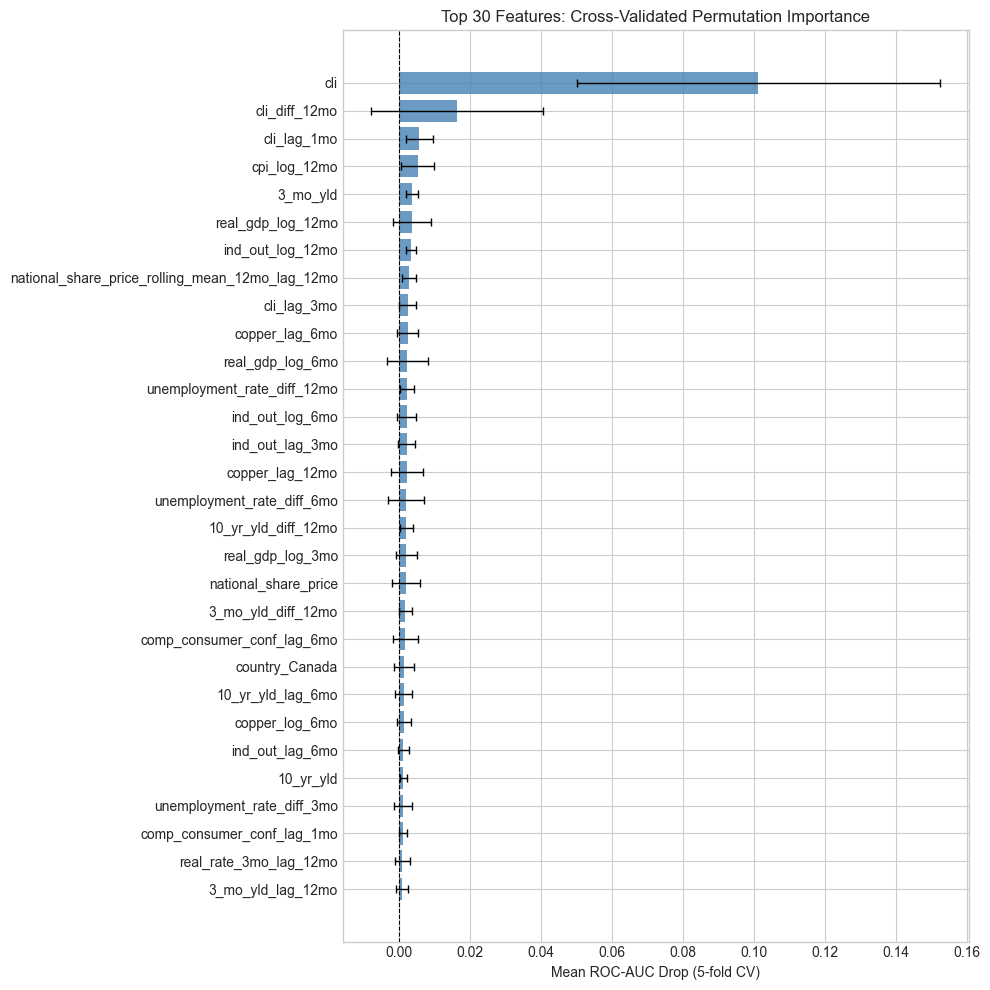

In [7]:
# Plot top 30 features by permutation importance with error bars
top_n_perm = 30
plot_df = perm_df.head(top_n_perm).sort_values('perm_mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(
    plot_df['feature'],
    plot_df['perm_mean'],
    xerr=plot_df['perm_std'],
    capsize=3,
    color='steelblue',
    alpha=0.8,
    error_kw={'elinewidth': 1, 'capthick': 1}
)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean ROC-AUC Drop (5-fold CV)')
ax.set_title(f'Top {top_n_perm} Features: Cross-Validated Permutation Importance')
plt.tight_layout()
plt.show()

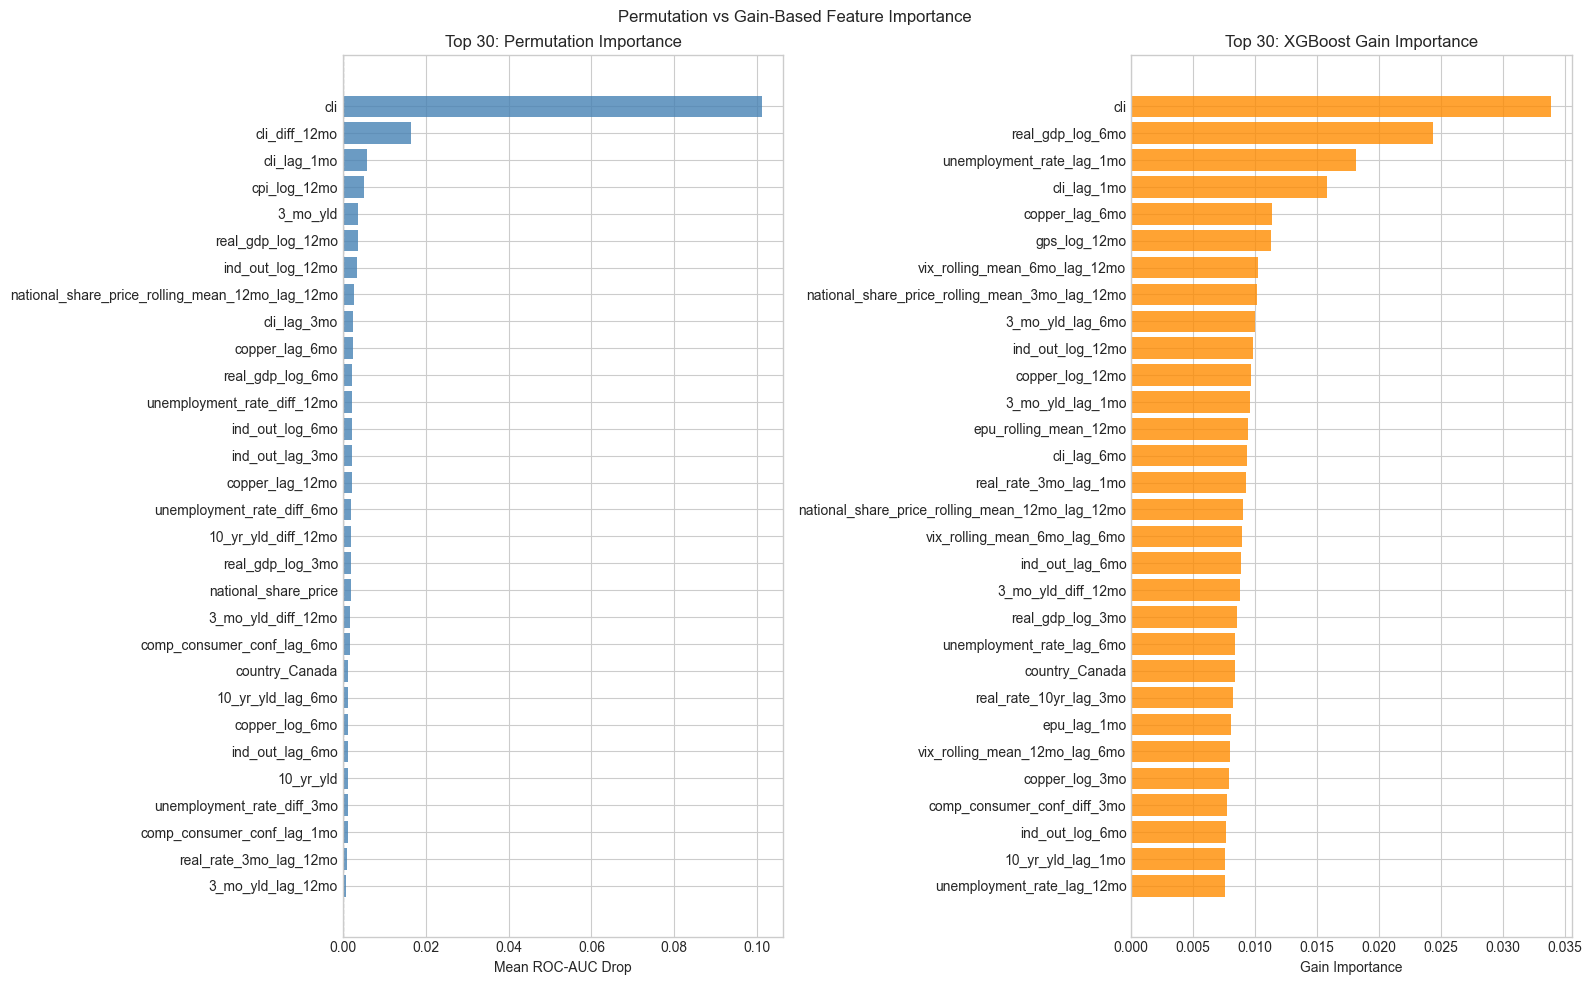

In top-30 permutation but NOT top-30 gain: {'cli_lag_3mo', 'comp_consumer_conf_lag_1mo', '3_mo_yld', '10_yr_yld_lag_6mo', 'cpi_log_12mo', 'comp_consumer_conf_lag_6mo', 'unemployment_rate_diff_6mo', 'unemployment_rate_diff_3mo', 'unemployment_rate_diff_12mo', 'real_rate_3mo_lag_12mo', 'national_share_price', 'ind_out_lag_3mo', '10_yr_yld', '10_yr_yld_diff_12mo', 'cli_diff_12mo', 'copper_log_6mo', 'real_gdp_log_12mo', '3_mo_yld_lag_12mo', 'copper_lag_12mo'}
In top-30 gain but NOT top-30 permutation: {'3_mo_yld_lag_1mo', 'cli_lag_6mo', 'vix_rolling_mean_6mo_lag_6mo', 'national_share_price_rolling_mean_3mo_lag_12mo', 'copper_log_12mo', 'real_rate_10yr_lag_3mo', 'unemployment_rate_lag_1mo', '3_mo_yld_lag_6mo', 'vix_rolling_mean_6mo_lag_12mo', 'real_rate_3mo_lag_1mo', 'epu_rolling_mean_12mo', 'copper_log_3mo', 'epu_lag_1mo', 'unemployment_rate_lag_12mo', 'gps_log_12mo', 'comp_consumer_conf_diff_3mo', '10_yr_yld_lag_1mo', 'unemployment_rate_lag_6mo', 'vix_rolling_mean_12mo_lag_6mo'}


In [8]:
# Compare permutation vs gain importance (top 30 side by side)
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

top30_perm = perm_df.head(30).sort_values('perm_mean', ascending=True)
axes[0].barh(top30_perm['feature'], top30_perm['perm_mean'], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Mean ROC-AUC Drop')
axes[0].set_title('Top 30: Permutation Importance')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')

top30_gain = gain_importance[features_after_corr].sort_values(ascending=False).head(30).sort_values(ascending=True)
axes[1].barh(top30_gain.index, top30_gain.values, color='darkorange', alpha=0.8)
axes[1].set_xlabel('Gain Importance')
axes[1].set_title('Top 30: XGBoost Gain Importance')

plt.suptitle('Permutation vs Gain-Based Feature Importance', fontsize=12)
plt.tight_layout()
plt.show()

# Features that rank differently between the two methods
top_perm_set = set(perm_df.head(30)['feature'])
top_gain_set = set(gain_importance[features_after_corr].nlargest(30).index)
print(f'In top-30 permutation but NOT top-30 gain: {top_perm_set - top_gain_set}')
print(f'In top-30 gain but NOT top-30 permutation: {top_gain_set - top_perm_set}')

In [9]:
# Select features with positive permutation importance
perm_df['robustly_positive'] = (perm_df['perm_mean'] - perm_df['perm_std']) > 0

features_perm_selected = perm_df[perm_df['perm_mean'] > 0]['feature'].tolist()
features_perm_robust = perm_df[perm_df['robustly_positive']]['feature'].tolist()

print(f'Features with perm_mean > 0:          {len(features_perm_selected)}')
print(f'Features with (mean - std) > 0:       {len(features_perm_robust)}')
print(f'\nPermutation-selected features:')
for f in features_perm_selected:
    row = perm_df[perm_df['feature'] == f].iloc[0]
    print(f'  {f:50s}  mean={row["perm_mean"]:.4f}  std={row["perm_std"]:.4f}')

Features with perm_mean > 0:          88
Features with (mean - std) > 0:       15

Permutation-selected features:
  cli                                                 mean=0.1013  std=0.0512
  cli_diff_12mo                                       mean=0.0163  std=0.0242
  cli_lag_1mo                                         mean=0.0057  std=0.0037
  cpi_log_12mo                                        mean=0.0052  std=0.0047
  3_mo_yld                                            mean=0.0036  std=0.0018
  real_gdp_log_12mo                                   mean=0.0036  std=0.0054
  ind_out_log_12mo                                    mean=0.0033  std=0.0015
  national_share_price_rolling_mean_12mo_lag_12mo     mean=0.0027  std=0.0019
  cli_lag_3mo                                         mean=0.0024  std=0.0023
  copper_lag_6mo                                      mean=0.0023  std=0.0030
  real_gdp_log_6mo                                    mean=0.0023  std=0.0059
  unemployment_rate_diff_12m

### Step 3: LASSO (L1) Feature Selection

Logistic Regression with L1 penalty drives uninformative feature coefficients
to exactly zero, performing implicit feature selection. Multiple regularization
strengths (C values) are evaluated to assess sensitivity.

Note: LASSO requires imputation (median) and StandardScaler since it is
sensitive to feature scale. This step operates on the correlation-reduced set.

In [10]:
# Impute and scale (required for L1 logistic regression)
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_imp = imputer.fit_transform(X_reduced)
X_scaled = scaler.fit_transform(X_imp)

# Sweep regularization strengths
C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

lasso_results = {}

for C in C_values:
    lasso = LogisticRegression(
        penalty='l1',
        solver='saga',
        C=C,
        max_iter=5000,
        random_state=42,
        class_weight='balanced'
    )
    lasso.fit(X_scaled, y)

    coef = pd.Series(lasso.coef_[0], index=features_after_corr)
    selected = coef[coef != 0].index.tolist()
    lasso_results[C] = {
        'n_selected': len(selected),
        'selected': selected,
        'coef': coef
    }
    print(f'C={C:6.3f}  ->  {len(selected):3d} features selected')

C_primary = 0.05
features_lasso_selected = lasso_results[C_primary]['selected']
print(f'\nPrimary LASSO selection (C={C_primary}): {len(features_lasso_selected)} features')

C= 0.001  ->    4 features selected
C= 0.005  ->    7 features selected
C= 0.010  ->   25 features selected
C= 0.050  ->   80 features selected
C= 0.100  ->  101 features selected
C= 0.500  ->  148 features selected
C= 1.000  ->  166 features selected

Primary LASSO selection (C=0.05): 80 features


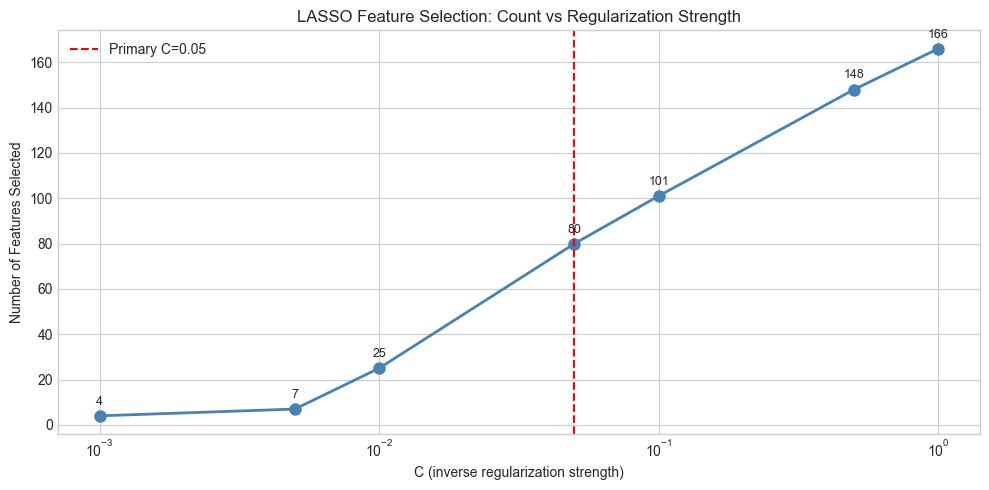

In [11]:
# Feature count vs regularization strength
c_vals = list(lasso_results.keys())
n_sels = [lasso_results[c]['n_selected'] for c in c_vals]

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(c_vals, n_sels, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axvline(x=C_primary, color='red', linestyle='--', label=f'Primary C={C_primary}')
ax.set_xlabel('C (inverse regularization strength)')
ax.set_ylabel('Number of Features Selected')
ax.set_title('LASSO Feature Selection: Count vs Regularization Strength')
ax.legend()
for c, n in zip(c_vals, n_sels):
    ax.annotate(str(n), (c, n), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)
plt.tight_layout()
plt.show()

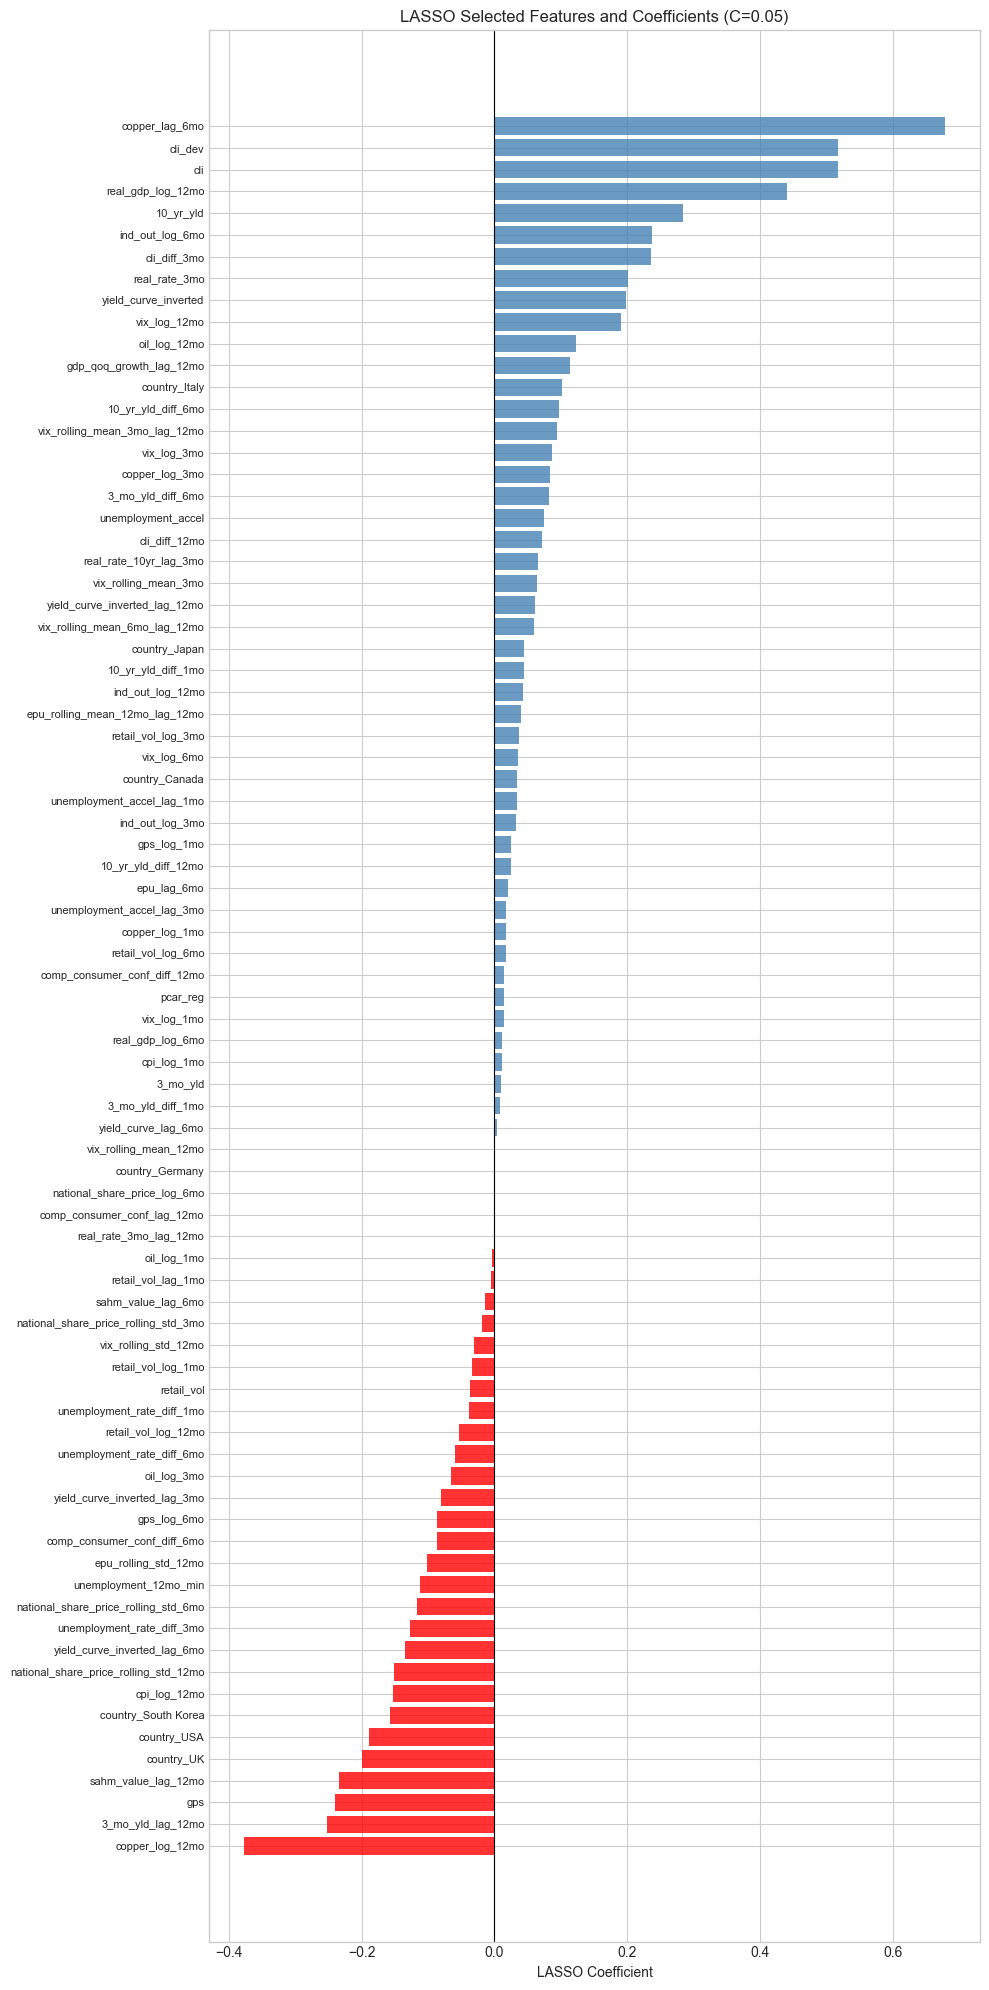

In [12]:
# LASSO coefficient plot for primary C value
coef_primary = lasso_results[C_primary]['coef']
nonzero_coef = coef_primary[coef_primary != 0].sort_values()

fig, ax = plt.subplots(figsize=(10, max(6, len(nonzero_coef) * 0.25)))
colors = ['red' if v < 0 else 'steelblue' for v in nonzero_coef.values]
ax.barh(nonzero_coef.index, nonzero_coef.values, color=colors, alpha=0.8)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('LASSO Coefficient')
ax.set_title(f'LASSO Selected Features and Coefficients (C={C_primary})')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

### Step 4: Consensus Feature Selection + Final Evaluation

Aggregate results from all three selection methods:
- Step 1 (Correlation): features surviving the |r| > 0.90 filter
- Step 2 (Permutation): features with mean permutation importance > 0
- Step 3 (LASSO): features with non-zero coefficient at C=0.05

A consensus feature is one selected by at least 2 of the 3 methods.
The final model is re-evaluated using only the consensus features.

In [13]:
# Build consensus feature set
set_corr = set(features_after_corr)
set_perm = set(features_perm_selected)
set_lasso = set(features_lasso_selected)

# Count how many methods selected each feature (perm + lasso; corr is the baseline gate)
consensus_records = []
for feat in features_after_corr:
    in_perm = feat in set_perm
    in_lasso = feat in set_lasso
    n_methods = int(in_perm) + int(in_lasso)
    consensus_records.append({
        'feature': feat,
        'in_perm': in_perm,
        'in_lasso': in_lasso,
        'n_methods': n_methods,
        'perm_mean': perm_df.set_index('feature')['perm_mean'].get(feat, np.nan),
        'gain_importance': gain_importance.get(feat, 0)
    })

consensus_df = pd.DataFrame(consensus_records).sort_values(
    ['n_methods', 'perm_mean'], ascending=[False, False]
).reset_index(drop=True)

features_consensus_any = consensus_df[consensus_df['n_methods'] >= 1]['feature'].tolist()
features_consensus_both = consensus_df[consensus_df['n_methods'] >= 2]['feature'].tolist()

print(f'Features passing corr filter (Step 1):   {len(features_after_corr)}')
print(f'Features selected by perm (Step 2):       {len(set_perm)}')
print(f'Features selected by LASSO (Step 3):      {len(set_lasso)}')
print(f'Consensus (perm OR lasso):                 {len(features_consensus_any)}')
print(f'Consensus (perm AND lasso):                {len(features_consensus_both)}')
print(f'\nConsensus (perm AND lasso) features:')
for f in features_consensus_both:
    row = consensus_df[consensus_df['feature'] == f].iloc[0]
    print(f'  {f:55s}  perm={row["perm_mean"]:.4f}  gain={row["gain_importance"]:.4f}')

Features passing corr filter (Step 1):   208
Features selected by perm (Step 2):       88
Features selected by LASSO (Step 3):      80
Consensus (perm OR lasso):                 132
Consensus (perm AND lasso):                36

Consensus (perm AND lasso) features:
  cli                                                      perm=0.1013  gain=0.0339
  cli_diff_12mo                                            perm=0.0163  gain=0.0044
  cpi_log_12mo                                             perm=0.0052  gain=0.0048
  3_mo_yld                                                 perm=0.0036  gain=0.0044
  real_gdp_log_12mo                                        perm=0.0036  gain=0.0049
  ind_out_log_12mo                                         perm=0.0033  gain=0.0098
  copper_lag_6mo                                           perm=0.0023  gain=0.0113
  real_gdp_log_6mo                                         perm=0.0023  gain=0.0244
  ind_out_log_6mo                                          per

In [14]:
# Reusable CV evaluation helper (identical XGBoost config to Baseline)

def run_cv_xgb(X_subset, y, n_splits=5):
    """Run 5-fold time-series CV with XGBoost, return mean ROC-AUC and PR-AUC."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    roc_aucs, pr_aucs = [], []

    for train_idx, test_idx in tscv.split(X_subset):
        X_tr, X_te = X_subset.iloc[train_idx], X_subset.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        spw = (y_tr == 0).sum() / (y_tr == 1).sum()

        model = xgb.XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            scale_pos_weight=spw, random_state=42, n_jobs=-1, verbosity=0
        )
        model.fit(X_tr, y_tr)
        y_proba = model.predict_proba(X_te)[:, 1]

        roc_aucs.append(roc_auc_score(y_te, y_proba))
        prec, rec, _ = precision_recall_curve(y_te, y_proba)
        pr_aucs.append(auc(rec, prec))

    return np.mean(roc_aucs), np.std(roc_aucs), np.mean(pr_aucs), np.std(pr_aucs)

In [15]:
# Evaluate all feature set thresholds
eval_sets = {
    'All 234 features (original baseline)': X[feature_cols],
    f'Corr-reduced ({len(features_after_corr)} features)': X_reduced,
    f'Perm OR LASSO ({len(features_consensus_any)} features)': X_reduced[features_consensus_any],
    f'Perm AND LASSO ({len(features_consensus_both)} features)': X_reduced[features_consensus_both],
}

final_results = {}
for label, X_eval in eval_sets.items():
    roc, roc_std, pr, pr_std = run_cv_xgb(X_eval, y)
    final_results[label] = {
        'n_features': X_eval.shape[1],
        'roc_auc': roc,
        'roc_std': roc_std,
        'pr_auc': pr,
        'pr_std': pr_std
    }
    print(f'{label}')
    print(f'  ROC-AUC: {roc:.3f} \u00b1 {roc_std:.3f}   PR-AUC: {pr:.3f} \u00b1 {pr_std:.3f}')
    print()

final_df = pd.DataFrame(final_results).T

All 234 features (original baseline)
  ROC-AUC: 0.698 ± 0.047   PR-AUC: 0.383 ± 0.085

Corr-reduced (208 features)
  ROC-AUC: 0.692 ± 0.063   PR-AUC: 0.375 ± 0.083

Perm OR LASSO (132 features)
  ROC-AUC: 0.711 ± 0.061   PR-AUC: 0.411 ± 0.102

Perm AND LASSO (36 features)
  ROC-AUC: 0.723 ± 0.068   PR-AUC: 0.453 ± 0.094



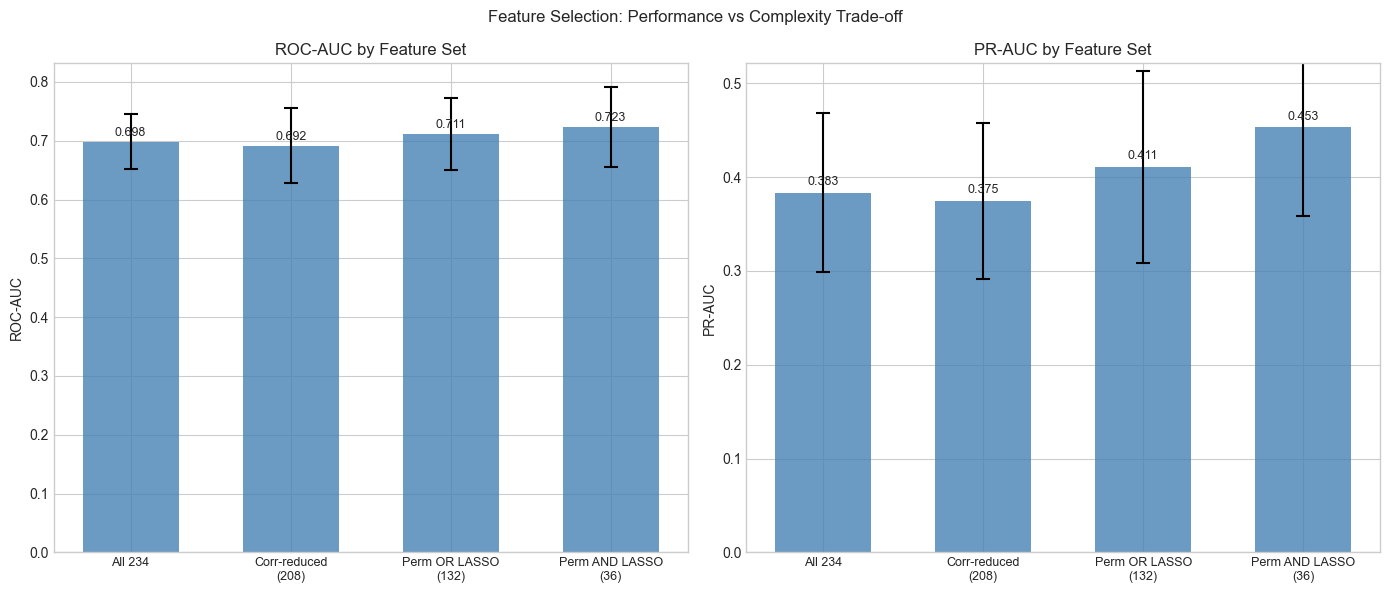

In [16]:
# Final comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

labels_short = [
    f'All 234',
    f'Corr-reduced\n({len(features_after_corr)})',
    f'Perm OR LASSO\n({len(features_consensus_any)})',
    f'Perm AND LASSO\n({len(features_consensus_both)})',
]
x = np.arange(len(labels_short))
width = 0.6

for ax_i, metric in enumerate(['roc_auc', 'pr_auc']):
    means = [final_results[k][metric] for k in final_results]
    stds = [final_results[k][metric.replace('auc', 'std')] for k in final_results]
    bars = axes[ax_i].bar(x, means, width, yerr=stds, capsize=5,
                          color='steelblue', alpha=0.8, error_kw={'capthick': 1.5})
    axes[ax_i].set_xticks(x)
    axes[ax_i].set_xticklabels(labels_short, fontsize=9)
    axes[ax_i].set_ylabel(metric.upper().replace('_', '-'))
    axes[ax_i].set_title(f'{metric.upper().replace("_", "-")} by Feature Set')
    axes[ax_i].set_ylim(0, max(means) * 1.15)
    for bar, val in zip(bars, means):
        axes[ax_i].text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.005,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Feature Selection: Performance vs Complexity Trade-off', fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
# Export final selected feature list
selected_features = features_consensus_both

print(f'Final selected feature set: {len(selected_features)} features')
print(f'Reduction from original 234: {234 - len(selected_features)} features removed '
      f'({(234 - len(selected_features)) / 234:.1%})')

import pickle
with open('data/selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

print('\nExported to: data/selected_features.pkl')
print('\nFinal selected features:')
for i, feat in enumerate(sorted(selected_features), 1):
    print(f'  {i:3d}. {feat}')

Final selected feature set: 36 features
Reduction from original 234: 198 features removed (84.6%)

Exported to: data/selected_features.pkl

Final selected features:
    1. 10_yr_yld
    2. 10_yr_yld_diff_12mo
    3. 10_yr_yld_diff_6mo
    4. 3_mo_yld
    5. 3_mo_yld_diff_6mo
    6. 3_mo_yld_lag_12mo
    7. cli
    8. cli_diff_12mo
    9. comp_consumer_conf_diff_12mo
   10. copper_lag_6mo
   11. copper_log_12mo
   12. copper_log_1mo
   13. country_Canada
   14. country_Italy
   15. cpi_log_12mo
   16. gps
   17. ind_out_log_12mo
   18. ind_out_log_6mo
   19. national_share_price_log_6mo
   20. national_share_price_rolling_std_6mo
   21. oil_log_3mo
   22. real_gdp_log_12mo
   23. real_gdp_log_6mo
   24. real_rate_10yr_lag_3mo
   25. real_rate_3mo_lag_12mo
   26. retail_vol_log_12mo
   27. retail_vol_log_1mo
   28. unemployment_12mo_min
   29. unemployment_accel
   30. unemployment_accel_lag_1mo
   31. unemployment_accel_lag_3mo
   32. unemployment_rate_diff_3mo
   33. unemployment_rate_

### Summary

| Step | Method | Description |
|------|--------|-------------|
| 1 | Correlation removal | Drop one of each pair with \|r\| > 0.90 (lower gain importance dropped) |
| 2 | Permutation importance | 5-fold CV, keep features with mean ROC-AUC drop > 0 |
| 3 | LASSO L1 (C=0.05) | Keep features with non-zero coefficients |
| 4 | Consensus (perm AND lasso) | Final selected set for downstream modeling |

**Selected features exported to:** `data/selected_features.pkl`